# Central Limit Theorem — convergence to a normal distribution

We draw samples from a non-Gaussian distribution (Bernoulli), form sums of $N$ such draws, and measure how close the empirical density of the (standardized) sum is to a standard normal density as $N$ grows.

The error is the MSE between the histogram-based density and the analytic Gaussian density, evaluated on the histogram bin centers.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(0)

## Setup

- Base distribution: Bernoulli($p$) with mean $\mu = p$ and variance $\sigma^2 = p(1-p)$.
- For each $N$, draw `n_trials` sums of $N$ Bernoulli variables and standardize:
  $$ Z = \frac{S_N - N\mu}{\sqrt{N}\,\sigma}. $$
- Compare the histogram density of $Z$ to $\mathcal{N}(0, 1)$.

In [42]:
p = 0.3                      # Bernoulli parameter (asymmetric -> slower convergence)
n_trials = 1000          # number of standardized sums drawn per N
N_values = np.arange(1, 201)
n_bins = 80                  # histogram bins on a fixed range
hist_range = (-5, 5)

mu = p
sigma = np.sqrt(p * (1 - p))

bin_edges = np.linspace(*hist_range, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
gauss_density = norm.pdf(bin_centers)

In [43]:
def standardized_sum_samples(N, n_trials, p, rng):
    """Draw n_trials sums of N Bernoulli(p) and standardize."""
    S = rng.binomial(N, p, size=n_trials)  # sum of N Bernoulli(p)
    return (S - N * p) / (np.sqrt(N) * np.sqrt(p * (1 - p)))

mse_values = []
densities = {}

for N in N_values:
    Z = standardized_sum_samples(N, n_trials, p, rng)
    density, _ = np.histogram(Z, bins=bin_edges, density=True)
    mse = np.mean((density - gauss_density) ** 2)
    mse_values.append(mse)
    densities[N] = density

mse_values = np.array(mse_values)

## MSE vs number of summed variables

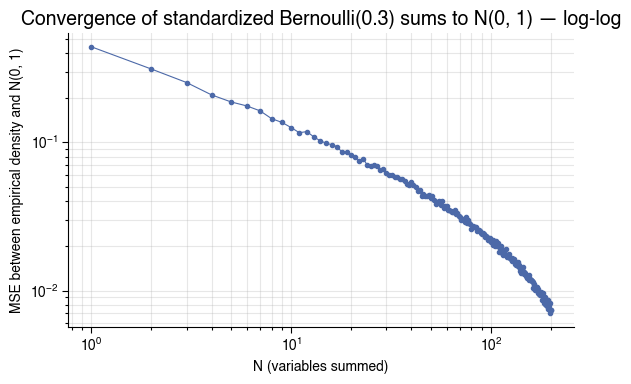

In [44]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(N_values, mse_values, marker='o', markersize=3, linewidth=0.8)
ax.set_xlabel('N (variables summed)')
ax.set_ylabel('MSE between empirical density and N(0, 1)')
ax.set_title(f'Convergence of standardized Bernoulli({p}) sums to N(0, 1) — log-log')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

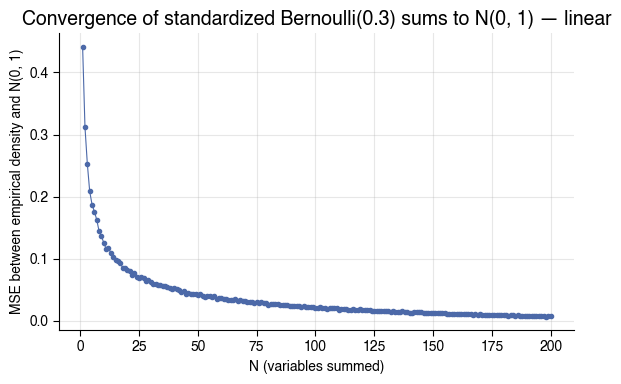

In [45]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(N_values, mse_values, marker='o', markersize=3, linewidth=0.8)
ax.set_xlabel('N (variables summed)')
ax.set_ylabel('MSE between empirical density and N(0, 1)')
ax.set_title(f'Convergence of standardized Bernoulli({p}) sums to N(0, 1) — linear')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Empirical densities for a few values of N

For small $N$ the density of the standardized sum is discrete and far from Gaussian; as $N$ grows it fills in and matches the bell curve.

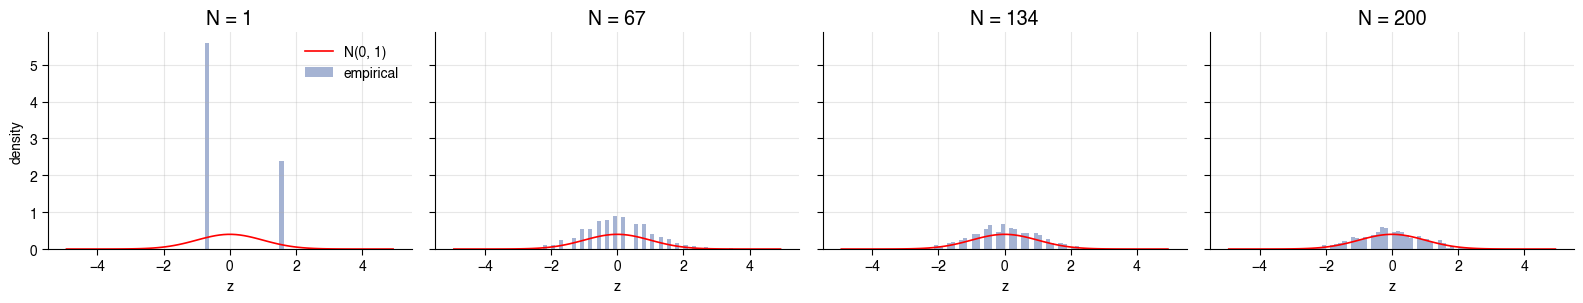

In [46]:
show_N = [N_values[0], N_values[len(N_values) // 3], N_values[2 * len(N_values) // 3], N_values[-1]]
fig, axes = plt.subplots(1, len(show_N), figsize=(4 * len(show_N), 3.2), sharey=True)
for ax, N in zip(axes, show_N):
    ax.bar(bin_centers, densities[N], width=bin_edges[1] - bin_edges[0],
           alpha=0.5, label='empirical')
    ax.plot(bin_centers, gauss_density, 'r-', label='N(0, 1)')
    ax.set_title(f'N = {N}')
    ax.set_xlabel('z')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('density')
axes[0].legend()
plt.tight_layout()
plt.show()